### Create Gaussian Process around dataset

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from agent.components.GaussianProcess import GASK
from agent.components.commons import ServiceType


s_type = ServiceType.QR
df = pd.read_csv("../statics/metrics_TSC_EXPLORE.csv")
# 2. Initialize and train
gp = GASK(s_type, show_figures=False)
gp.init_model(df, data_density=1.0)

INFO:multiscale:Training data contains service types <StringArray>
[  'elastic-workbench-qr-detector',   'elastic-workbench-cv-analyzer',
 'elastic-workbench-pc-visualizer']
Length: 3, dtype: str
INFO:GP_Model:Fitting GP for elastic-workbench-qr-detector - Target: max_tp
INFO:multiscale:train_gp_models took 409 ms to execute


### Gaussian Process gives you µ,s for an arbitrary point

In [2]:
import numpy as np
%load_ext autoreload
%autoreload 2

# gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0})
# gp.predict(s_type, "max_tp", {'data_quality': 10000, 'cores': 600.0})
# gp.predict(s_type, "max_tp", {'data_quality': 100, 'cores': 6.0, 'model_size': 2.0})


from agent.components.commons import ServiceVar
from typing import Dict, Tuple



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Test if the global optimizer converges to a nice result

In [3]:
from agent.components.GaussianProcess import get_empirical_variable_bounds
%load_ext autoreload
%autoreload 2

from agent.components.Optimizer import local_obj, solve_global
from agent.components.SLORegistry_v2 import SLO_Registry

slo_lib = SLO_Registry("../statics/config/service_level_objectives.yml")
slos = slo_lib.get_slo_for_client("experiment-1", "client-1")

empirical_var_bounds = get_empirical_variable_bounds(gp.training_data)[s_type]
print(empirical_var_bounds)

starting_point = [6.0, 400] + ([1.0] if s_type == ServiceType.CV else [])
# print(local_obj(starting_point, ServiceType.QR, slos, rask_gp, list(empirical_bounds.values())))
solve_global(s_type, slos, gp, empirical_var_bounds, last_assignments=starting_point)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
{<ServiceVar.COST: 'cores'>: (np.float64(1.0), np.float64(6.0)), <ServiceVar.QUALITY: 'data_quality'>: (np.int64(101), np.int64(990)), <ServiceVar.PERFORMANCE: 'max_tp'>: (np.float64(14.285714285714286), np.float64(1666.6666666666665))}


[np.float64(4.131581009823283), np.float64(101.0)]

### Test how much the epsilon should be moved each iteration

In [4]:
import numpy as np

# Convert to a numpy array so we can do math on the whole vector
x_norm = np.array([0.1] * (3 if s_type == ServiceType.CV else 2))

simple_param_bounds = get_empirical_variable_bounds(gp.training_data)[s_type]
del simple_param_bounds[ServiceVar.PERFORMANCE]
simple_param_bounds = list(simple_param_bounds.values())

for e in [1e-5, 1e-3, 1e-2, 5e-2]:
    # val_start uses the original center
    val_start = local_obj(x_norm, s_type, slos, gp, simple_param_bounds)

    # x_norm + e now adds 'e' to every element (e.g., [0.11, 0.11])
    val_nudge = local_obj(x_norm + e, s_type, slos, gp, simple_param_bounds)

    diff = abs(val_start - val_nudge)
    print(f"Eps {e}: Change in SLO-F is {diff:.6f}")

Eps 1e-05: Change in SLO-F is 0.000019
Eps 0.001: Change in SLO-F is 0.001927
Eps 0.01: Change in SLO-F is 0.018354
Eps 0.05: Change in SLO-F is 0.073812


### Create versatile map of different solutions

Iteration 0: Elite found in bin (np.int64(3), np.int64(0)) with fitness 0.4288
Iteration 100: Elite found in bin (np.int64(7), np.int64(1)) with fitness 0.6976
Iteration 300: Elite found in bin (np.int64(5), np.int64(8)) with fitness 0.0065
Iteration 1200: Elite found in bin (np.int64(2), np.int64(3)) with fitness 0.0673
Iteration 1300: Elite found in bin (np.int64(8), np.int64(3)) with fitness 0.1756


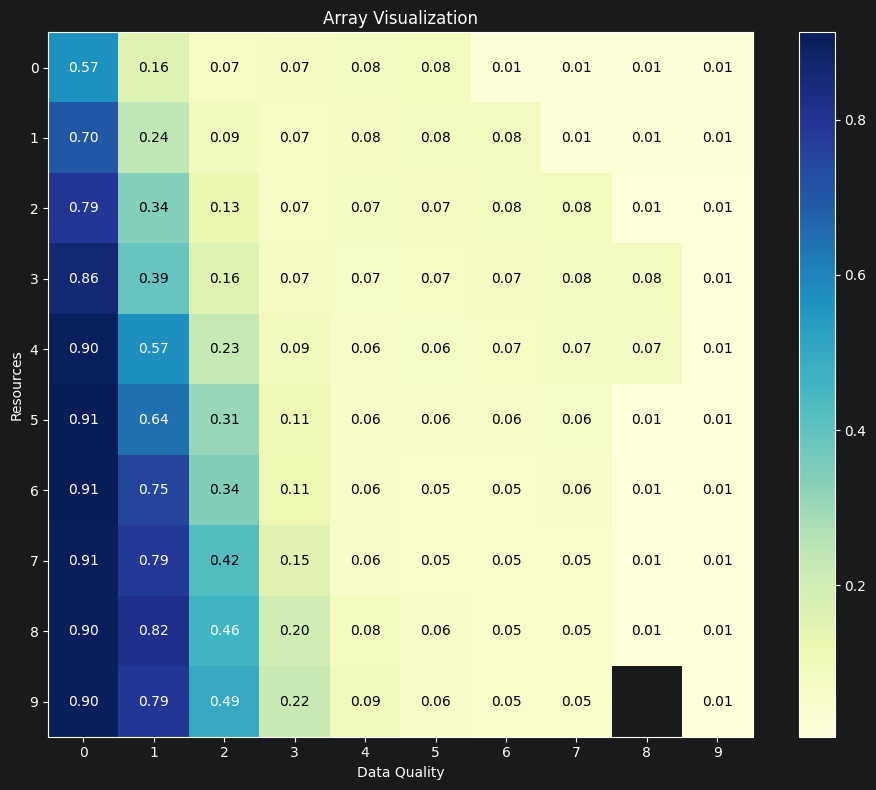

Versatile Candidate: {'coord': array([0.62141975, 0.        ]), 'fitness': np.float64(0.9124918082796653)}
Versatile Candidate: {'coord': array([0.93483834, 0.04414711]), 'fitness': np.float64(0.9028993066228828)}
Versatile Candidate: {'coord': array([0.32956193, 0.        ]), 'fitness': np.float64(0.7906725601162687)}
Versatile Candidate: {'coord': array([0.06700731, 0.        ]), 'fitness': np.float64(0.5702330507628127)}
Versatile Candidate: {'coord': array([0.73572185, 0.22450346]), 'fitness': np.float64(0.343765744895144)}
Versatile Candidate: {'coord': array([1.        , 0.33344649]), 'fitness': np.float64(0.2214865599914581)}
Versatile Candidate: {'coord': array([0.4044893 , 0.22496506]), 'fitness': np.float64(0.16354997222670742)}
Versatile Candidate: {'coord': array([0.00204416, 0.63401216]), 'fitness': np.float64(0.08357364083615153)}
Versatile Candidate: {'coord': array([0.29362969, 0.86399393]), 'fitness': np.float64(0.07952328746397921)}
Versatile Candidate: {'coord': arra

In [5]:
from utils import visualize_ndarray
from agent.components.Optimizer import VersatileMapElites

# 1. Initialize
v_me = VersatileMapElites(s_type, bins=10)

#  I'm getting the black cells because they are not explored.
#  What I can do is force all cells to be explored at least once,
#  or just run gradient descent for each cell multiple (like 5) times.
# 2. Run the illumination
v_me.run_search(slos, gp, simple_param_bounds, iterations=2000)
visualize_ndarray(v_me.fitness_table)

# 3. Get n solutions that are high-performing but far apart
diverse_set = v_me.get_diverse_set(n_solutions=10, versatility=0.2)
print("\n".join(f"Versatile Candidate: {x}" for x in diverse_set))
